Supervised Learning using pandas

All Module Imports Successful!
Dataset loaded successfully!
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      189 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
Remaining missing values: 0


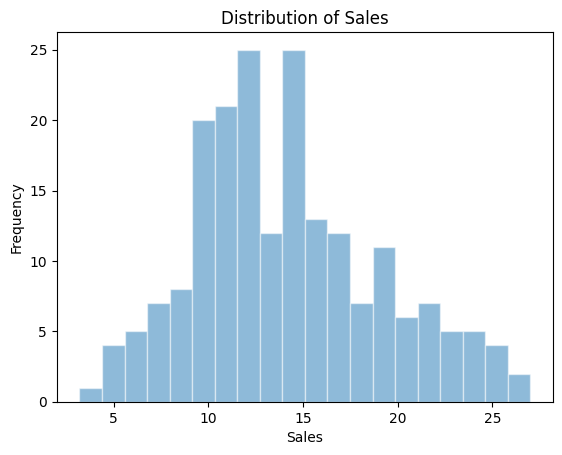

✅ Model trained!
MAE  : 1.74
RMSE : 2.31
R²   : 0.8270

📌 R² of 0.83 means the model explains 82.70% of the variance in sales.

📌 Prediction Sales Graph


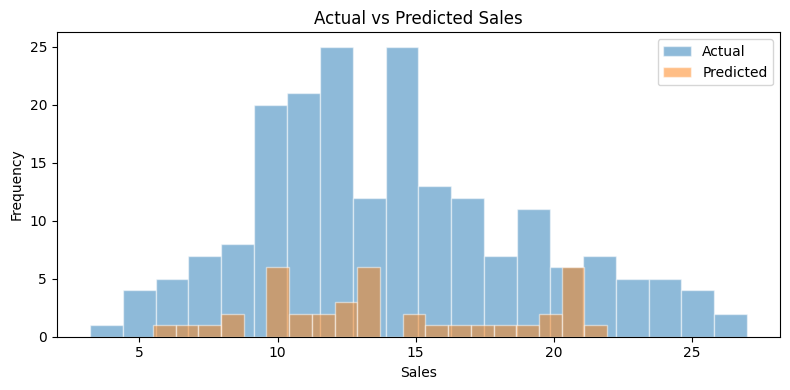

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("All Module Imports Successful!")

try:
    df = pd.read_csv('Advertising.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please check the file path.")

df.head()
df.info()
df.describe()

df.isnull().sum()

df.fillna(df.mean(), inplace=True)
print('Remaining missing values:', df.isnull().sum().sum())

plt.hist(df['Sales'], bins=20, alpha=0.5, edgecolor='white')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

features = ['TV', 'Radio', 'Newspaper']
X = df[features]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print('✅ Model trained!')

y_pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R²   : {r2:.4f}')
print(f'\n📌 R² of {r2:.2f} means the model explains {r2*100:.2f}% of the variance in sales.')

y_pred = np.array(y_pred).squeeze()

print(f'\n📌 Prediction Sales Graph')

df['Predicted_Sales'] = np.nan
df.loc[X_test.index, 'Predicted_Sales'] = y_pred
plt.figure(figsize=(8, 4))

plt.hist(df['Sales'], bins=20, alpha=0.5, label='Actual', edgecolor='white')
plt.hist(df['Predicted_Sales'].dropna(), bins=20, alpha=0.5, label='Predicted', edgecolor='white')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()